# Curvature comparison (three networks)

Reads the `Forman` and `OR_MMOT` hyperedge-curvature files for three networks and makes a
single figure with **three panels side by side**: `Forman` vs `OR_MMOT`, one panel per network.

Each point is a hyperedge, coloured by its cardinality. Files are expected in the usual
`<hyperedge key> : <curvature>` format, e.g. `1,4,17 : -0.8932`.

In [8]:
import os

import numpy as np
import matplotlib.pyplot as plt
from matplotlib.colors import BoundaryNorm
from scipy.stats import pearsonr, spearmanr

## 1. The files

`DATASET_IDS` is the only thing to edit: the folder names under
`../results/synthetic_data/` for the three networks to compare.

In [14]:
RESULTS_DIR = os.path.join("..", "results")

# <-- specify the three IDs to compare here
DATASET_IDS = ["ID_D", "ID_E", "ID_H"]


def curvature_paths(dataset_dir):
    """The two hyperedge curvature files for one network."""
    return {
        "Forman": os.path.join(dataset_dir, "hyperedge", "Forman_curvature.txt"),
        "OR_MMOT": os.path.join(dataset_dir, "hyperedge", "OR_MMOT_curvature.txt"),
    }


NETWORKS = {
    dataset_id: curvature_paths(os.path.join(RESULTS_DIR, "synthetic_data", dataset_id))
    for dataset_id in DATASET_IDS
}

for name, paths in NETWORKS.items():
    for measure, path in paths.items():
        print(f"{name:8s} {measure:8s} {'ok ' if os.path.exists(path) else 'MISSING'} {path}")

ID_D     Forman   ok  ..\results\synthetic_data\ID_D\hyperedge\Forman_curvature.txt
ID_D     OR_MMOT  ok  ..\results\synthetic_data\ID_D\hyperedge\OR_MMOT_curvature.txt
ID_E     Forman   ok  ..\results\synthetic_data\ID_E\hyperedge\Forman_curvature.txt
ID_E     OR_MMOT  ok  ..\results\synthetic_data\ID_E\hyperedge\OR_MMOT_curvature.txt
ID_H     Forman   ok  ..\results\synthetic_data\ID_H\hyperedge\Forman_curvature.txt
ID_H     OR_MMOT  ok  ..\results\synthetic_data\ID_H\hyperedge\OR_MMOT_curvature.txt


## 2. Loading

In [15]:
def read_curvature_file(path):
    """'1,4,17 : -0.89' lines -> {frozenset of nodes: curvature}."""
    curvatures = {}
    with open(path, "r") as f:
        for line in f:
            line = line.strip()
            if not line or ":" not in line:
                continue
            key, value = line.rsplit(":", 1)
            nodes = frozenset(n.strip() for n in key.strip().split(",") if n.strip())
            curvatures[nodes] = float(value)
    return curvatures


def load_network(paths):
    """Load the measures and align them on the hyperedges they share."""
    measures = {name: read_curvature_file(path) for name, path in paths.items()}

    shared = set.intersection(*(set(m) for m in measures.values()))
    hyperedges = sorted(shared, key=lambda e: (len(e), sorted(e)))

    data = {name: np.array([m[e] for e in hyperedges]) for name, m in measures.items()}
    data["cardinality"] = np.array([len(e) for e in hyperedges])
    return data


networks = {name: load_network(paths) for name, paths in NETWORKS.items()}

for name, data in networks.items():
    cards = data["cardinality"]
    print(f"{name}: {len(cards)} shared hyperedges, cardinality {cards.min()}-{cards.max()}")

ID_D: 2503 shared hyperedges, cardinality 2-6
ID_E: 1027 shared hyperedges, cardinality 2-6
ID_H: 1027 shared hyperedges, cardinality 2-6


## 3. Plotting

In [ ]:
CMAP = plt.get_cmap("viridis")
POINT_SIZE = 22


def compare_measures(networks, x_measure="Forman", y_measure="OR_MMOT", figsize=(17, 5)):
    """One panel per network: x_measure vs y_measure, coloured by hyperedge cardinality."""
    all_cards = np.concatenate([d["cardinality"] for d in networks.values()])
    levels = np.arange(all_cards.min(), all_cards.max() + 2) - 0.5
    norm = BoundaryNorm(levels, CMAP.N)

    fig, axes = plt.subplots(1, len(networks), figsize=figsize, constrained_layout=True)
    axes = np.atleast_1d(axes)

    for ax, (name, data) in zip(axes, networks.items()):
        x, y = data[x_measure], data[y_measure]
        scatter = ax.scatter(x, y, c=data["cardinality"], cmap=CMAP, norm=norm,
                             s=POINT_SIZE, alpha=0.8, linewidths=0)

        r = pearsonr(x, y)[0]
        rho = spearmanr(x, y)[0]
        ax.set_title(f"(n = {len(x)})\nPearson r = {r:.3f},  Spearman $\\rho$ = {rho:.3f}")
        ax.set_xlabel(f"{x_measure} curvature")
        ax.set_ylabel(f"{y_measure} curvature")
        ax.grid(alpha=0.3)

    cbar = fig.colorbar(scatter, ax=axes, ticks=np.unique(all_cards))
    cbar.set_label("hyperedge cardinality")

    fig.suptitle(f"{x_measure} vs {y_measure}", fontsize=14)
    return fig

### Forman vs OR_MMOT — three networks side by side

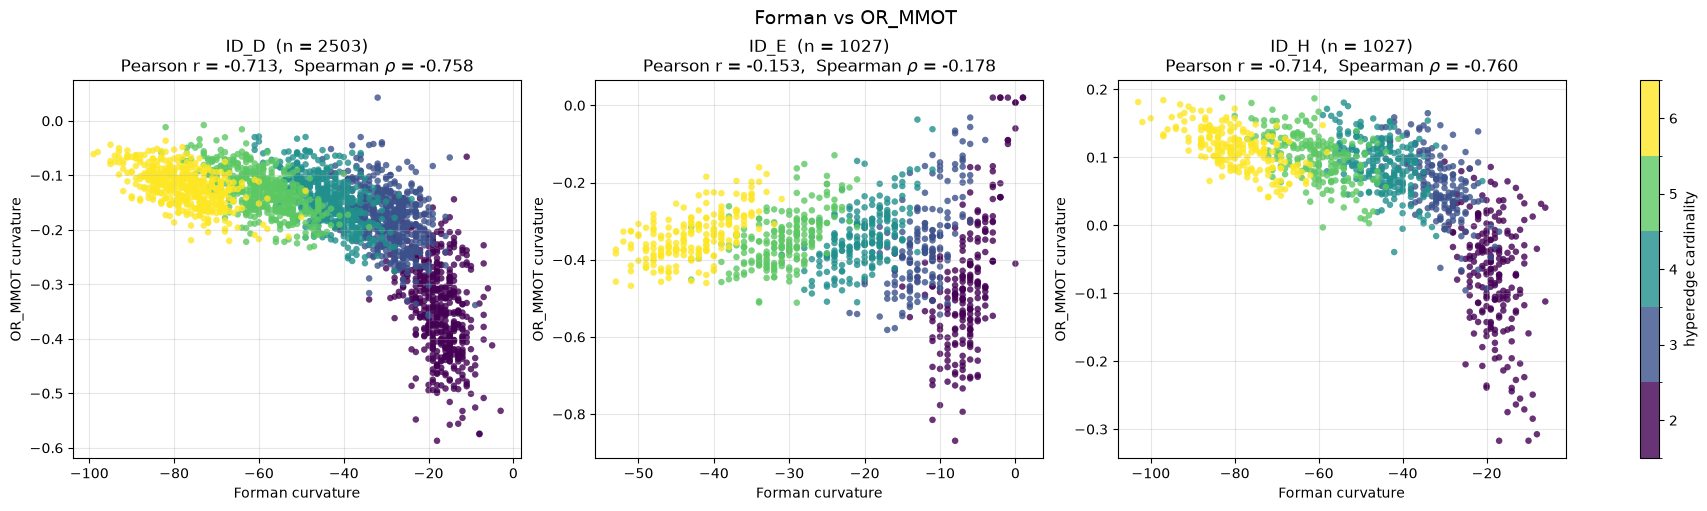

In [17]:
fig = compare_measures(networks)
plt.show()

### Optional — save the figure

In [18]:
OUT_DIR = os.path.join("..", "figures")
os.makedirs(OUT_DIR, exist_ok=True)

fig = compare_measures(networks)
out_path = os.path.join(OUT_DIR, f"Forman_vs_OR_MMOT_{'_'.join(DATASET_IDS)}.png")
fig.savefig(out_path, dpi=300, bbox_inches="tight")
plt.close(fig)
print("saved", out_path)

saved ..\figures\Forman_vs_OR_MMOT_ID_D_ID_E_ID_H.png
